It should be quite obvious that the linear model may not always be the best choice for modeling the relation between variables. If we expect the relation to be represented by some other type of function there are several ways to proceed. For a start let us look at polynomials. For this case we can create what we call dummy variables to represent monomials that are not in the first power, based on the samples we have and treat the relation as an linear model. For example let's say that we have reasons to belive that the relation is quadratic so $Y \sim aX^2 +bX +c$. Having the sample $X$ we create the dummy variable $Z=X^2$ and try to fit a linear model for $Y \sim Z+X$. The next two exercises are meant to explore this concept.

Create a normal random variable of size 100, call it x, and define a random variable with the formula $y=2x^3+x^2-2x+3$. Create the proper dummy variables and create a regression model for y assuming that it is described by a polynomial of the degree 3. Create also a regression model for y assuming that it is described by a polynomial of the degree 2 and compare results.  

Warning message in summary.lm(model):
“essentially perfect fit: summary may be unreliable”



Call:
lm(formula = y ~ poly(x, degree = 3))

Residuals:
       Min         1Q     Median         3Q        Max 
-4.672e-15 -7.982e-16  1.963e-16  8.249e-16  7.939e-15 

Coefficients:
                      Estimate Std. Error   t value Pr(>|t|)    
(Intercept)          5.267e+00  1.696e-16 3.106e+16   <2e-16 ***
poly(x, degree = 3)1 5.985e+01  1.696e-15 3.529e+16   <2e-16 ***
poly(x, degree = 3)2 3.185e+01  1.696e-15 1.878e+16   <2e-16 ***
poly(x, degree = 3)3 4.835e+01  1.696e-15 2.851e+16   <2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 1.696e-15 on 96 degrees of freedom
Multiple R-squared:      1,	Adjusted R-squared:      1 
F-statistic: 8.036e+32 on 3 and 96 DF,  p-value: < 2.2e-16


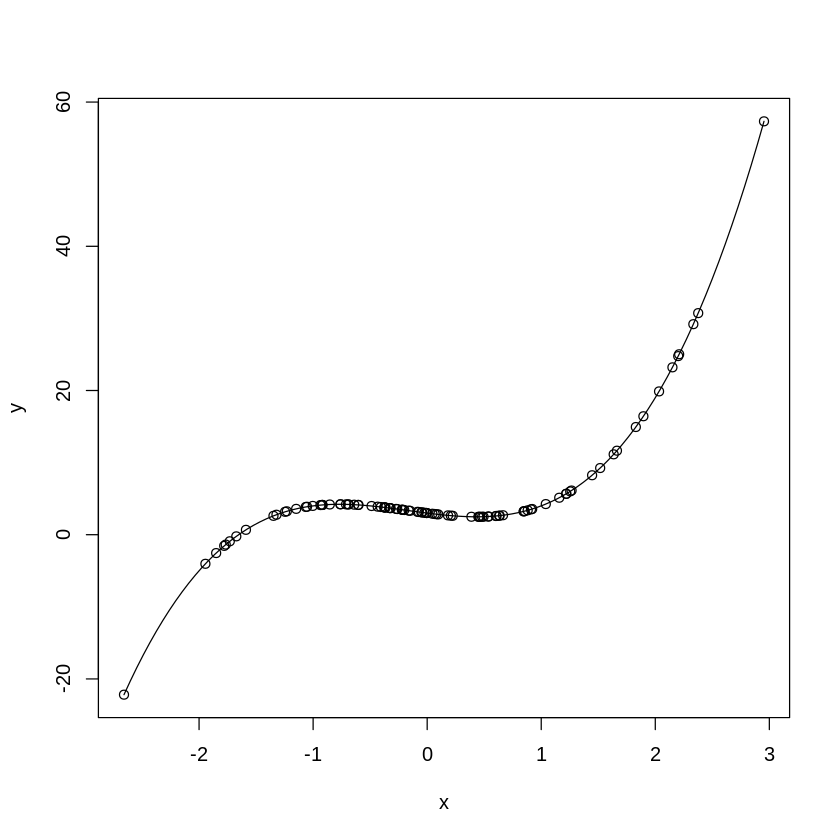

In [ ]:
x <- rnorm(100)

y <- 2*x^3 + x^2 - 2*x + 3

model <- lm(y ~ poly(x, degree = 3))

summary(model)

plot(x, y)
x_seq <- seq(min(x), max(x), length.out = 100)
lines(x_seq, predict(model, newdata = data.frame(x = x_seq)))


Call:
lm(formula = y ~ poly(x, degree = 2))

Residuals:
     Min       1Q   Median       3Q      Max 
-21.2378  -4.2013  -0.9584   3.5191  27.0063 

Coefficients:
                     Estimate Std. Error t value Pr(>|t|)    
(Intercept)             2.810      0.616   4.562 1.48e-05 ***
poly(x, degree = 2)1   61.248      6.160   9.943  < 2e-16 ***
poly(x, degree = 2)2  -44.223      6.160  -7.180 1.42e-10 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 6.16 on 97 degrees of freedom
Multiple R-squared:  0.608,	Adjusted R-squared:  0.5999 
F-statistic: 75.21 on 2 and 97 DF,  p-value: < 2.2e-16


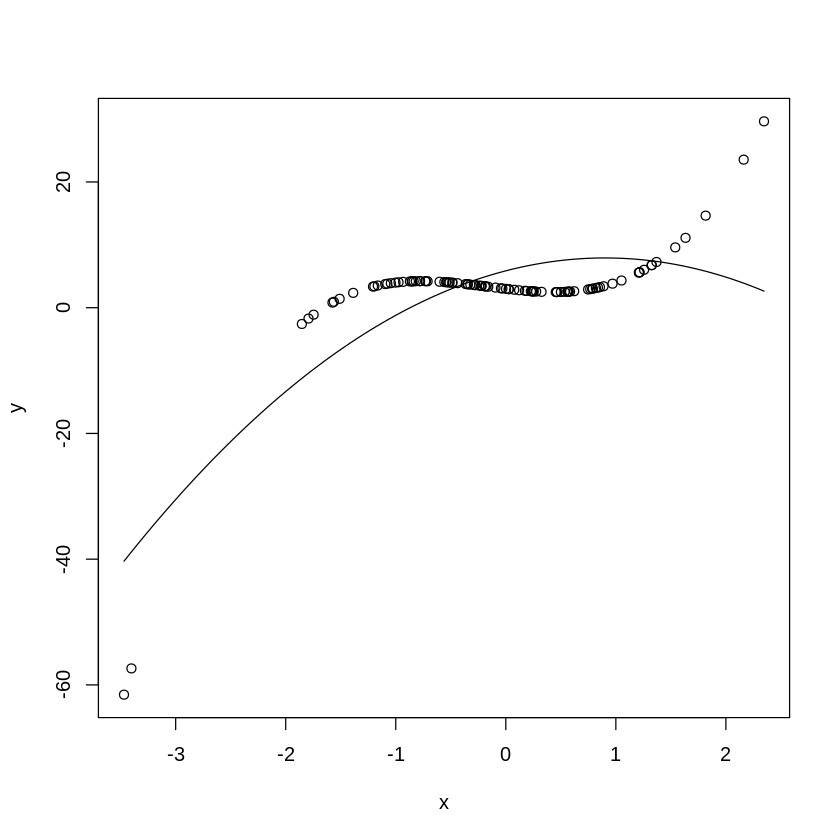

In [ ]:
model <- lm(y ~ poly(x, degree = 2))

summary(model)

plot(x, y)
x_seq <- seq(min(x), max(x), length.out = 100)
lines(x_seq, predict(model, newdata = data.frame(x = x_seq)))

Create a normal random variable of size 100, call it b,  create another normal random variable of size 100, call it a, and define a random variable with the formula $y=a^2 +ab -b^2$. Create the proper dummy variables and create a regression model for y assuming that it is described by a polynomial.

In [ ]:
b <- rnorm(100)
a <- rnorm(100)

y <- a^2 + a*b - b^2

model <- lm(y ~ poly(a, 2) + poly(b, 2) + a:b)

summary(model)

Warning message in summary.lm(model):
“essentially perfect fit: summary may be unreliable”



Call:
lm(formula = y ~ poly(a, 2) + poly(b, 2) + a:b)

Residuals:
       Min         1Q     Median         3Q        Max 
-4.544e-15 -2.169e-16  8.700e-18  1.636e-16  4.548e-15 

Coefficients:
              Estimate Std. Error    t value Pr(>|t|)    
(Intercept) -5.216e-02  9.018e-17 -5.784e+14   <2e-16 ***
poly(a, 2)1  2.248e+00  9.350e-16  2.404e+15   <2e-16 ***
poly(a, 2)2  1.209e+01  9.391e-16  1.287e+16   <2e-16 ***
poly(b, 2)1 -1.709e+00  9.079e-16 -1.883e+15   <2e-16 ***
poly(b, 2)2 -1.314e+01  9.729e-16 -1.350e+16   <2e-16 ***
a:b          1.000e+00  1.062e-16  9.417e+15   <2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 8.935e-16 on 94 degrees of freedom
Multiple R-squared:      1,	Adjusted R-squared:      1 
F-statistic: 1.1e+32 on 5 and 94 DF,  p-value: < 2.2e-16


We can also use functions prepared to deal with nonlinear regression models. One of the easiest to use in this case is the nls() function. It will require to give a formula that describes the kind of relation you expect from the variables, and we need to give a starting point for the parameters we are trying to estimate. Read about the function and try to model the next exercise.

Create a uniform random variable of size 100 (lets call it $X$), a normal random variable b with mean 0 and sd 3, and create a random variable $Y$ which is equal to $Y=X^{2,5}-b$. Use the nls function to estimate the parameters in the regression model $Y$ $\sim$ $X^a+b$.

In [ ]:
X <- runif(100)
b <- rnorm(1,mean = 0, sd = 3)
Y <- X^2.5 - b

nls(Y ~ X^a + b, start = list(a = 2, b = 0), algorithm = "port")

Nonlinear regression model
  model: Y ~ X^a + b
   data: parent.frame()
     a      b 
 2.500 -1.337 
 residual sum-of-squares: 6.533e-31

Algorithm "port", convergence message: X-convergence (3)

In all of the exercises till now our dependent variable was quantitative. But we can also create linear regression models for qualitative variables, with a little bit of work. For example we can create a linear model if the dependent variable is binary, like for example the patient is sick/healthy, or the student passed/did not pass the exam. We call this logistic regression. For that purpose we use the generalized linear model function glm(). One of its parameters is is family. If We set this parameter to "gaussian" we get the standard linear model. If it is set to "binomial" we get logistic regression. Several functions that work for lm() work also for glm(), like summary(), predict(), or step(). The next few examples focus around logistic regression.

For the data in daneO create a logistic regression model that describes the Niepowodzenia variable by the Nowotwor variable and the logarithm of the VEGF variable. Next use the step function to find which variables are best to describe the Niepowodzenia variable.

In [ ]:
dane_oh <- read.csv2("Data/daneO.csv")
dane_oh$Niepowodzenia <- ifelse(dane_oh$Niepowodzenia == "brak", 0, 1)
head(dane_oh)

model1 <- glm(Niepowodzenia ~ VEGF,family = "binomial", data = dane_oh)
summary(model1)

,Wiek,Rozmiar.guza,Wezly.chlonne,Nowotwor,Receptory.estrogenowe,Receptory.progesteronowe,Niepowodzenia,Okres.bez.wznowy,VEGF
,<int>,<int>,<int>,<int>,<chr>,<chr>,<dbl>,<int>,<int>
1,29,1,0,2,(-),(++),0,22,914
2,29,1,0,2,(++),(++),0,53,1118
3,30,1,1,2,(-),(+),0,38,630
4,32,1,0,3,(++),(++),0,26,1793
5,32,2,0,NA,(-),(++),0,19,963
6,33,1,1,3,(-),(++),1,36,2776



Call:
glm(formula = Niepowodzenia ~ VEGF, family = "binomial", data = dane_oh)

Coefficients:
              Estimate Std. Error z value Pr(>|z|)    
(Intercept) -2.499e+00  4.124e-01  -6.059 1.37e-09 ***
VEGF         1.877e-04  7.154e-05   2.624  0.00869 ** 
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

(Dispersion parameter for binomial family taken to be 1)

    Null deviance: 76.428  on 96  degrees of freedom
Residual deviance: 68.463  on 95  degrees of freedom
AIC: 72.463

Number of Fisher Scoring iterations: 4


For the data in daneO create a linear regression model that describes the Niepowodzenia variable by the Nowotwor variable and use it to predict the chances of reminission of cancer depending on the variable Nowotwor.

In [ ]:
model2 <- lm(Niepowodzenia ~ Nowotwor, data = dane_oh)
summary(model2)


Call:
lm(formula = Niepowodzenia ~ Nowotwor, data = dane_oh)

Residuals:
    Min      1Q  Median      3Q     Max 
-0.3169 -0.1042 -0.1042 -0.1042  0.8958 

Coefficients:
            Estimate Std. Error t value Pr(>|t|)   
(Intercept) -0.32136    0.14556  -2.208  0.02998 * 
Nowotwor     0.21276    0.06342   3.355  0.00119 **
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 0.3404 on 84 degrees of freedom
  (11 observations deleted due to missingness)
Multiple R-squared:  0.1181,	Adjusted R-squared:  0.1077 
F-statistic: 11.25 on 1 and 84 DF,  p-value: 0.001194


The file Per.csv contains the data about heights of baby boys and girls in different families with some data missing. Create a data structure without missing data, use it to create a linear regression model and use it to predict and fill the missing values in the original data, and make a summary of that data. You may need to create two regression models, with each variable as the dependent.

In [ ]:
Per <- read.csv2('Data/Per.csv')
Per_complete <- na.omit(Per)

model_bro <- lm(brother ~ sister, data = Per_complete)
model_sis <- lm(sister ~ brother, data = Per_complete)

Per_filled <- Per
na_bro <- is.na(Per$brother)
na_sis <- is.na(Per$sister)

Per_filled$brother[na_bro] <- round(predict(model_bro, newdata = Per[na_bro, ]))
Per_filled$sister[na_sis]  <- round(predict(model_sis, newdata = Per[na_sis, ]))

summary(Per_filled)

For the data in daneO plot the conditional densities between VEGF and Niepowodzenia and, separately, between VEGF and Nowotwor. For this purpose read about and use the function cdplot().

In [ ]:
cdplot(as.factor(Niepowodzenia) ~ VEGF,
       data = na.omit(dane_oh[, c('Niepowodzenia', 'VEGF')]),
       main = 'VEGF vs Niepowodzenia')

cdplot(as.factor(Nowotwor) ~ VEGF,
       data = na.omit(dane_oh[, c('Nowotwor', 'VEGF')]),
       main = 'VEGF vs Nowotwor')